<h1> Decision Tree

So far, we have covered three different approaches:

| Model               | Core Idea                         |
| ------------------- | --------------------------------- |
| Logistic Regression | Finding a linear decision boundary |
| KNN                 | Decision-making based on sample similarity |
| Naive Bayes         | Probabilistic decision-making      |


Now we move on to:

Decision Tree 🌳

Its perspective is:

"How can we split data into distinct groups by asking a series of consecutive questions?"

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


from sklearn.tree import DecisionTreeClassifier
from src.decision_tree import (
    gini,
    entropy,
    best_split,
    DecisionTree,
)

<h3> Step 1: Dataset

In [39]:
df = pd.read_csv(
    "../../../datasets/Titanic-Dataset/processed/titanic_feature_engineered.csv"
)

df.head()

,Survived,Age,Fare,FamilySize,FarePerPerson,SibSp,Parch,Sex,Embarked,FamilyCategory,Title,Deck
0,0,22.0,7.2500,2,3.62500,1,0,male,S,Small,Mr,Unknown
1,1,38.0,71.2833,2,35.64165,1,0,female,C,Small,Mrs,C
2,1,26.0,7.9250,1,7.92500,0,0,female,S,Alone,Miss,Unknown
3,1,35.0,53.1000,2,26.55000,1,0,female,S,Small,Mrs,C
4,0,35.0,8.0500,1,8.05000,0,0,male,S,Alone,Mr,Unknown


In [40]:
X = df.drop(
    "Survived",
    axis=1
)

y = df["Survived"]

In [41]:
numeric_features = X.select_dtypes(
    include=[
        "int64",
        "float64"
    ]
).columns.tolist()


categorical_features = X.select_dtypes(
    include=[
        "object"
    ]
).columns.tolist()

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [43]:
numeric_transformer = Pipeline(
    steps=[
        
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[

        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [44]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

<h3> Step 2: Initial Test

In [45]:
y1 = np.array(
    [1,1,1,1]
)

print(gini(y1))
print(entropy(y1))

0.0
0.0


In [46]:
y2 = np.array(
    [0,0,1,1]
)

print(gini(y2))
print(entropy(y2))

0.5
1.0


<h3> Step 3: Finding the Best Split

This is the most important part of the algorithm.

At each node, the decision tree must decide:

Which feature and which threshold yield the greatest reduction in impurity?

In [47]:
X = np.array(
    [
        [2],
        [3],
        [10],
        [12]
    ]
)

y = np.array(
    [
        0,
        0,
        1,
        1
    ]
)

In [48]:
best_split(
    X,
    y,
    gini
)

(0, 3, 0.0)

In [49]:
best_split(
    X,
    y,
    entropy
)

(0, 3, 0.0)

<h3> Step 4: Building the Tree Recursively

A decision tree is a recursive algorithm.

If we always split, the tree becomes too large and memorizes the training data:

In other words:

$$ Overfitting $$

Therefore, we need a stopping condition.

<h3> Step 5: Prediction (Tree Traversal)

Model with Gini

In [50]:
tree_gini = DecisionTree(
    criterion="entropy",
    max_depth=3
)

tree_gini.fit(
    X,
    y
)

tree_gini.predict(
    X
)

array([0, 0, 1, 1], dtype=int64)

Model with Entropy

In [51]:
tree_entropy = DecisionTree(
    criterion="entropy",
    max_depth=3
)

tree_entropy.fit(
    X,
    y
)

tree_entropy.predict(
    X
)

array([0, 0, 1, 1], dtype=int64)

In [52]:
new_samples = np.array(
    [
        [5],
        [15]
    ]
)

tree_entropy.predict(
    new_samples
)

array([1, 1], dtype=int64)

In [53]:
test_samples = np.array(
    [
        [0],
        [1],
        [3],
        [3.1],
        [4],
        [100]
    ]
)

tree_entropy.predict(
    test_samples
)

array([0, 0, 0, 1, 1, 1], dtype=int64)

<h3> Step 5: Test on Titanic Dataset

gini

In [54]:
tree_gini = DecisionTree(
    criterion="gini",
    max_depth=5,
    min_samples_split=10
)

In [55]:
tree_gini.fit(
    X_train_processed,
    y_train.values
)

In [56]:
y_pred_gini = tree_gini.predict(
    X_test_processed
)

In [57]:
gini_accuracy = accuracy_score(
    y_test,
    y_pred_gini
)

gini_precision = precision_score(
    y_test,
    y_pred_gini
)

gini_recall = recall_score(
    y_test,
    y_pred_gini
)

gini_f1 = f1_score(
    y_test,
    y_pred_gini
)

gini_cm = confusion_matrix(
    y_test,
    y_pred_gini
)

print("Decision Tree - Gini")

print("Accuracy:", gini_accuracy)
print("Precision:", gini_precision)
print("Recall:", gini_recall)
print("F1-score:", gini_f1)
print("Confusion Matrix:")
print(gini_cm)

Decision Tree - Gini
Accuracy: 0.8212290502793296
Precision: 0.7534246575342466
Recall: 0.7971014492753623
F1-score: 0.7746478873239437
Confusion Matrix:
[[92 18]
 [14 55]]


Entropy

In [58]:
tree_entropy = DecisionTree(
    criterion="entropy",
    max_depth=5,
    min_samples_split=10
)

In [59]:
tree_entropy.fit(
    X_train_processed,
    y_train.values
)

In [60]:
y_pred_entropy = tree_entropy.predict(
    X_test_processed
)

In [61]:
entropy_accuracy = accuracy_score(
    y_test,
    y_pred_entropy
)

entropy_precision = precision_score(
    y_test,
    y_pred_entropy
)

entropy_recall = recall_score(
    y_test,
    y_pred_entropy
)

entropy_f1 = f1_score(
    y_test,
    y_pred_entropy
)

entropy_cm = confusion_matrix(
    y_test,
    y_pred_entropy
)

print("Decision Tree - Entropy")

print("Accuracy:", entropy_accuracy)
print("Precision:", entropy_precision)
print("Recall:", entropy_recall)
print("F1-score:", entropy_f1)
print("Confusion Matrix:")
print(entropy_cm)

Decision Tree - Entropy
Accuracy: 0.8156424581005587
Precision: 0.7647058823529411
Recall: 0.7536231884057971
F1-score: 0.759124087591241
Confusion Matrix:
[[94 16]
 [17 52]]


<h3> Step 6: Comparison with previous models

| Model                 | Accuracy |    F1 |
| --------------------- | -------: | ----: |
| Logistic Regression   |    82.7% | 76.3% |
| KNN                   |    82.1% | 75.8% |
| Naive Bayes           |    77.1% | 74.2% |
| Decision Tree Gini    |    82.1% | 77.5% |
| Decision Tree Entropy |    81.6% | 75.9% |


<h3> Step 7: Analyzing Overfitting in Decision Trees

This part is crucial, as it highlights one of the biggest weaknesses of decision trees:

If left uncontrolled, they very easily memorize the training data.

Why is a decision tree prone to overfitting?

Because the algorithm can perform so many splits that each sample essentially finds its own path.

In [62]:
depths = [
    1,
    2,
    3,
    5,
    7,
    10,
    15
]

train_scores = []
test_scores = []
f1_scores = []


for depth in depths:

    print(
        f"Max Depth: {depth}"
    )


    tree = DecisionTree(
        criterion="gini",
        max_depth=depth,
        min_samples_split=10
    )


    tree.fit(
        X_train_processed,
        y_train.values
    )


    # Train prediction

    y_train_pred = tree.predict(
        X_train_processed
    )


    # Test prediction

    y_test_pred = tree.predict(
        X_test_processed
    )


    train_accuracy = accuracy_score(
        y_train,
        y_train_pred
    )


    test_accuracy = accuracy_score(
        y_test,
        y_test_pred
    )


    test_f1 = f1_score(
        y_test,
        y_test_pred
    )


    train_scores.append(
        train_accuracy
    )


    test_scores.append(
        test_accuracy
    )


    f1_scores.append(
        test_f1
    )


    print(
        "Train Accuracy:",
        train_accuracy
    )

    print(
        "Test Accuracy:",
        test_accuracy
    )

    print(
        "Test F1:",
        test_f1
    )

    print("----------------")

Max Depth: 1
Train Accuracy: 0.7851123595505618
Test Accuracy: 0.770949720670391
Test F1: 0.7132867132867132
----------------
Max Depth: 2
Train Accuracy: 0.8202247191011236
Test Accuracy: 0.8044692737430168
Test F1: 0.736842105263158
----------------
Max Depth: 3
Train Accuracy: 0.8356741573033708
Test Accuracy: 0.7988826815642458
Test F1: 0.7499999999999999
----------------
Max Depth: 5
Train Accuracy: 0.8637640449438202
Test Accuracy: 0.8212290502793296
Test F1: 0.7746478873239437
----------------
Max Depth: 7
Train Accuracy: 0.8932584269662921
Test Accuracy: 0.7988826815642458
Test F1: 0.7428571428571428
----------------
Max Depth: 10
Train Accuracy: 0.9058988764044944
Test Accuracy: 0.7597765363128491
Test F1: 0.6814814814814815
----------------
Max Depth: 15
Train Accuracy: 0.922752808988764
Test Accuracy: 0.7597765363128491
Test F1: 0.6861313868613138
----------------


In [63]:
depth_results = pd.DataFrame(
    {
        "Max Depth": depths,

        "Train Accuracy": train_scores,

        "Test Accuracy": test_scores,

        "Test F1": f1_scores
    }
)


depth_results

,Max Depth,Train Accuracy,Test Accuracy,Test F1
0,1,0.785112,0.770950,0.713287
1,2,0.820225,0.804469,0.736842
2,3,0.835674,0.798883,0.750000
3,5,0.863764,0.821229,0.774648
4,7,0.893258,0.798883,0.742857
5,10,0.905899,0.759777,0.681481
6,15,0.922753,0.759777,0.686131


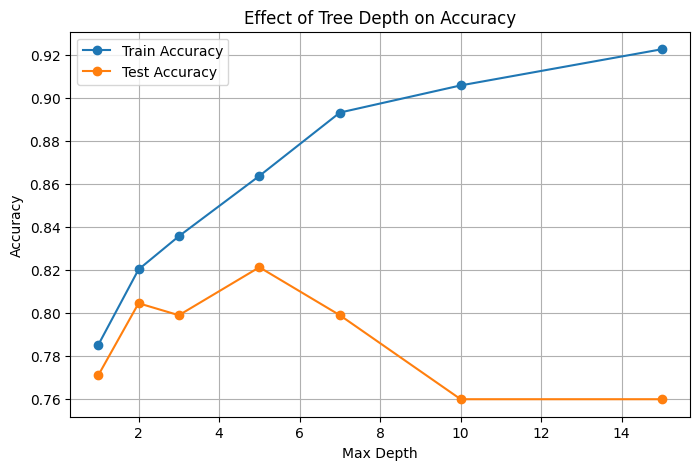

In [64]:
plt.figure(
    figsize=(8,5)
)


plt.plot(
    depths,
    train_scores,
    marker="o",
    label="Train Accuracy"
)


plt.plot(
    depths,
    test_scores,
    marker="o",
    label="Test Accuracy"
)


plt.xlabel(
    "Max Depth"
)


plt.ylabel(
    "Accuracy"
)


plt.title(
    "Effect of Tree Depth on Accuracy"
)


plt.legend()

plt.grid()

plt.show()

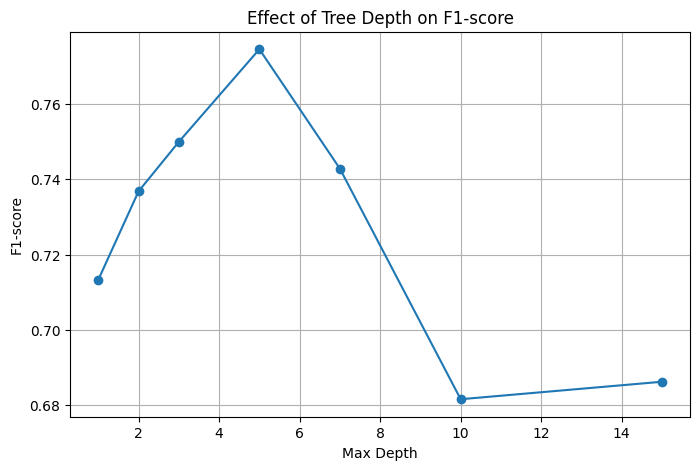

In [65]:
plt.figure(
    figsize=(8,5)
)


plt.plot(
    depths,
    f1_scores,
    marker="o"
)


plt.xlabel(
    "Max Depth"
)


plt.ylabel(
    "F1-score"
)


plt.title(
    "Effect of Tree Depth on F1-score"
)


plt.grid()

plt.show()

### Summary of Results Table


| Max Depth | Train Acc | Test Acc | Test F1 | رفتار            |
| --------- | --------: | -------: | ------: | ---------------- |
| 1         |     0.785 |    0.771 |   0.713 | Underfitting     |
| 2         |     0.821 |    0.805 |   0.736 | Improvement      |
| 3         |     0.836 |    0.799 |   0.750 | Godd             |
| 5         |     0.864 |    0.821 |   0.775 | The best spot    |
| 7         |     0.893 |    0.799 |   0.743 | Onset of Overfitting |
| 10        |     0.906 |    0.760 |   0.682 | Overfitting      |
| 15        |     0.923 |    0.760 |   0.686 | Severe overfitting |


### Effect of Tree Depth and Overfitting

Decision Trees are highly flexible models and can easily overfit when their depth increases.

In this experiment, different values of max_depth were evaluated.

For shallow trees, both training and testing performance were limited, indicating underfitting.

By increasing the depth, the model learned more complex patterns and performance improved.

The best generalization performance was achieved around max_depth=5.

After this point, training accuracy continued increasing while test performance decreased, demonstrating overfitting.

This experiment highlights the importance of controlling tree complexity using parameters such as max_depth and min_samples_split.

<h3> Step 8: Visualizing Our Decision Tree 🌳

In [66]:
tree_gini.print_tree()

Feature 16 <= 0.0
Left:
  Feature 2 <= 1.3329129401751731
  Left:
    Feature 1 <= -0.2877611150115036
    Left:
      Feature 18 <= 0.0
      Left:
        Feature 3 <= -0.28016857988382704
        Left:
          Leaf: 1
        Right:
          Leaf: 1
      Right:
        Leaf: 0
    Right:
      Feature 18 <= 0.0
      Left:
        Feature 1 <= -0.06470180256697296
        Left:
          Leaf: 1
        Right:
          Leaf: 1
      Right:
        Feature 27 <= 0.0
        Left:
          Leaf: 1
        Right:
          Leaf: 0
  Right:
    Feature 1 <= -0.2721443603479425
    Left:
      Leaf: 1
    Right:
      Feature 1 <= 0.7856304888639273
      Left:
        Feature 0 <= 1.4170066900568414
        Left:
          Leaf: 0
        Right:
          Leaf: 1
      Right:
        Leaf: 1
Right:
  Feature 3 <= 0.14867457915359422
  Left:
    Feature 22 <= 0.0
    Left:
      Feature 23 <= 0.0
      Left:
        Feature 1 <= -0.5142040576331391
        Left:
          Leaf: 0
 

In [67]:
feature_names = preprocessor.get_feature_names_out()

feature_names

array(['num__Age', 'num__Fare', 'num__FamilySize', 'num__FarePerPerson',
       'num__SibSp', 'num__Parch', 'cat__Sex_female', 'cat__Sex_male',
       'cat__Embarked_C', 'cat__Embarked_Q', 'cat__Embarked_S',
       'cat__FamilyCategory_Alone', 'cat__FamilyCategory_Large',
       'cat__FamilyCategory_Small', 'cat__Title_Master',
       'cat__Title_Miss', 'cat__Title_Mr', 'cat__Title_Mrs',
       'cat__Title_Rare', 'cat__Deck_A', 'cat__Deck_B', 'cat__Deck_C',
       'cat__Deck_D', 'cat__Deck_E', 'cat__Deck_F', 'cat__Deck_G',
       'cat__Deck_T', 'cat__Deck_Unknown'], dtype=object)

In [68]:
def plot_tree(
    tree,
    feature_names=None
):

    positions = {}
    edges = []

    counter = [0]


    def traverse(node, depth=0, x=0):

        node_id = counter[0]
        counter[0] += 1


        if node.value is not None:

            if feature_names is not None:
                label = f"Class = {node.value}"
            else:
                label = f"Leaf\nClass={node.value}"

        else:

            if feature_names is not None:
                feature = feature_names[node.feature]
            else:
                feature = f"Feature {node.feature}"

            label = (
                f"{feature}\n"
                f"<= {node.threshold:.2f}"
            )


        positions[node_id] = (
            x,
            -depth,
            label
        )


        if node.left is not None:

            left_id = traverse(
                node.left,
                depth + 1,
                x - 1/(depth+2)
            )

            edges.append(
                (node_id,left_id)
            )


        if node.right is not None:

            right_id = traverse(
                node.right,
                depth + 1,
                x + 1/(depth+2)
            )

            edges.append(
                (node_id,right_id)
            )


        return node_id


    traverse(
        tree.root
    )


    plt.figure(
        figsize=(12,8)
    )


    # Draw edges

    for parent, child in edges:

        x1,y1,_ = positions[parent]

        x2,y2,_ = positions[child]


        plt.plot(
            [x1,x2],
            [y1,y2],
            linewidth=1
        )


    # Draw nodes

    for node_id,(x,y,label) in positions.items():

        plt.scatter(
            x,
            y,
            s=2500
        )

        plt.text(
            x,
            y,
            label,
            ha="center",
            va="center",
            fontsize=8
        )


    plt.axis("off")

    plt.show()

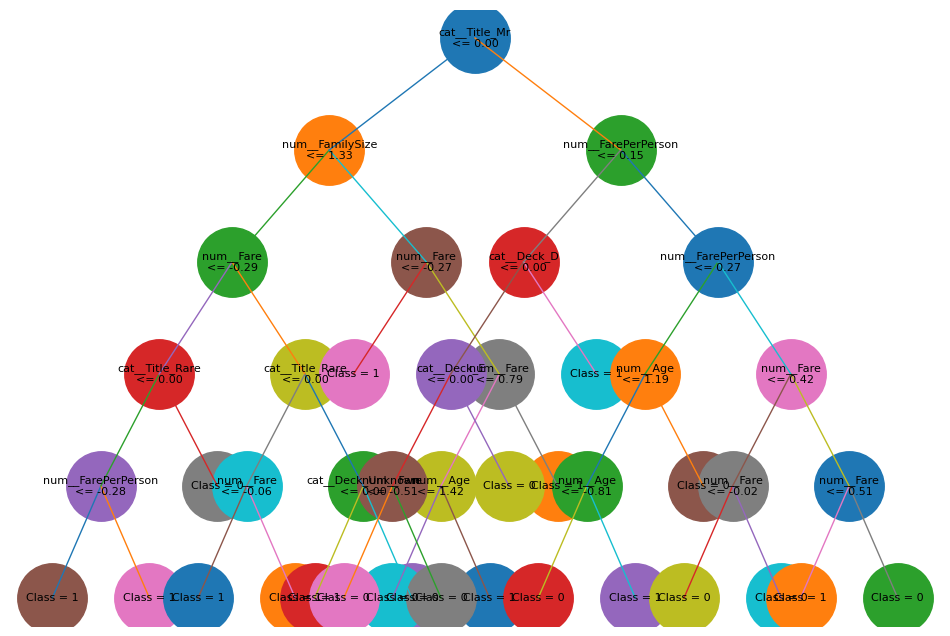

In [69]:
plot_tree(
    tree_gini,
    feature_names=feature_names
)

### Decision Tree Interpretability

The visualization demonstrates that the manually implemented Decision Tree learns human-interpretable rules based on passenger attributes. The root split selected Title_Mr as the most informative feature, followed by family-related and fare-related features, showing that demographic and socioeconomic factors contribute strongly to survival prediction.

<h3> Step 9: Comparing Custom Decision Tree vs Scikit-Learn DecisionTreeClassifier

In [70]:
sklearn_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

sklearn_tree.fit(
    X_train_processed,
    y_train
)

y_pred_sklearn_tree = sklearn_tree.predict(
    X_test_processed
)

sklearn_accuracy = accuracy_score(
    y_test,
    y_pred_sklearn_tree
)

sklearn_precision = precision_score(
    y_test,
    y_pred_sklearn_tree
)

sklearn_recall = recall_score(
    y_test,
    y_pred_sklearn_tree
)

sklearn_f1 = f1_score(
    y_test,
    y_pred_sklearn_tree
)

sklearn_cm = confusion_matrix(
    y_test,
    y_pred_sklearn_tree
)

In [71]:
decision_tree_comparison = pd.DataFrame(
    {
        "Model": [
            "Custom Decision Tree",
            "Scikit-Learn Decision Tree"
        ],

        "Accuracy": [
            gini_accuracy,
            sklearn_accuracy
        ],

        "Precision": [
            gini_precision,
            sklearn_precision
        ],

        "Recall": [
            gini_recall,
            sklearn_recall
        ],

        "F1-score": [
            gini_f1,
            sklearn_f1
        ],

        "Confusion Matrix": [
            gini_cm,
            sklearn_cm
        ]
    }
)

decision_tree_comparison

,Model,Accuracy,Precision,Recall,F1-score,Confusion Matrix
0,Custom Decision Tree,0.821229,0.753425,0.797101,0.774648,"[[92, 18], [14, 55]]"
1,Scikit-Learn Decision Tree,0.821229,0.753425,0.797101,0.774648,"[[92, 18], [14, 55]]"


In [72]:
np.array_equal(
    y_pred_gini,
    y_pred_sklearn_tree
)

True

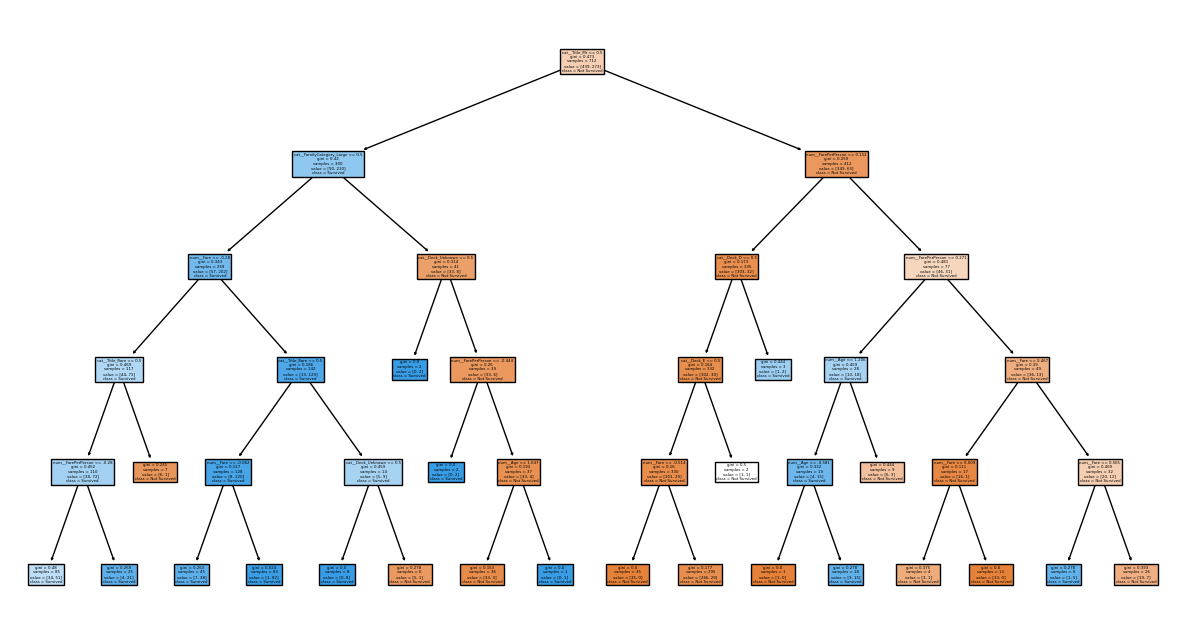

In [ ]:
plt.figure(
    figsize=(15,8)
)

tree.plot_tree(
    sklearn_tree,
    feature_names=feature_names,
    class_names=[
        "Not Survived",
        "Survived"
    ],
    filled=True
)

plt.show()

### Comparison with Scikit-Learn Decision Tree

To validate the custom implementation, the manually developed Decision Tree was compared with Scikit-Learn's DecisionTreeClassifier using the same dataset, preprocessing pipeline, splitting criterion, and hyperparameters.

Both models achieved identical performance:

- Accuracy: 82.12%</br>
- Precision: 75.34%</br>
- Recall: 79.71%</br>
- F1-score: 77.46%

The identical confusion matrices demonstrate that the custom implementation successfully reproduces the behavior of a standard Decision Tree classifier.

Although Scikit-Learn provides a highly optimized implementation with additional features and computational improvements, building the algorithm from scratch helped understand the fundamental mechanisms behind tree construction, impurity reduction, and recursive decision making.